# Trotter step size and SKQD accuracy

In [1]:
import os
import sys
from pathlib import Path
from functools import partial
import logging
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from scipy.linalg import eigh, eigvalsh
import h5py
import jax
import jax.numpy as jnp
from jax.sharding import PartitionSpec, NamedSharding
from jax.experimental.ode import odeint
from qiskit.quantum_info import SparsePauliOp
from heavyhex_qft.triangular_z2 import TriangularZ2Lattice
from skqd_z2lgt.parameters import Parameters
from skqd_z2lgt.extensions import denoising, perturbation_2q
from skqd_z2lgt.circuits import make_plaquette_circuits
from skqd_z2lgt.mwpm import minimum_weight_link_state
from skqd_z2lgt.sqd import sqd
from skqd_z2lgt.utils import read_bits
from skqd_z2lgt.tasks.common import make_dual_lattice
from skqd_z2lgt.jax_experimental_sparse_linalg import lobpcg_standard
sys.path.append('/home/iiyama/src/skqd_z2lgt/lib')
from unitary_krylov import make_hvec, make_trotter_uvec, integrate, simulate, sample, exact_diag, compute_gen_eigvals

logging.basicConfig(level=logging.INFO)
os.environ['CUDA_VISIBLE_DEVICES'] = '0'
jax.config.update('jax_enable_x64', True)

data_dir = Path('/data/iiyama/2dz2/unitary_krylov')

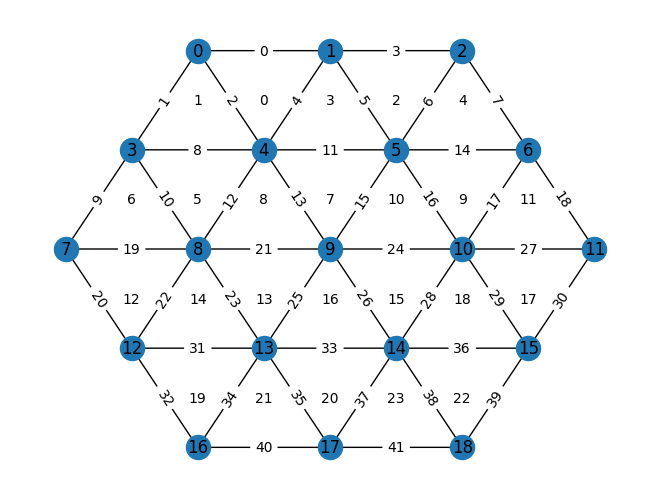

In [2]:
config = '''
  * * *
 * * * *
* * * * *
 * * * *
  * * *
'''

lattice = TriangularZ2Lattice(config)
lattice.draw_graph();

In [3]:
plaquette_energy = 1.
charged_vertices = [1, 17]

base_link_state = minimum_weight_link_state(charged_vertices, lattice)
print(np.nonzero(base_link_state[::-1])[0])
dual_lattice = lattice.plaquette_dual(base_link_state)
nplaq = dual_lattice.num_plaquettes
hamiltonian = dual_lattice.make_hamiltonian(plaquette_energy)

[ 5 15 25 35]


In [4]:
delta_t = 0.4
key = jax.random.key(1234)
trotter_uvec = make_trotter_uvec(hamiltonian, delta_t)
sim_states = simulate(trotter_uvec, nplaq, 4, num_substeps=1)[1:]
probs = jnp.square(jnp.abs(sim_states))


INFO:2025-12-10 10:01:45,854:jax._src.xla_bridge:822: Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: libtpu.so: cannot open shared object file: No such file or directory
INFO:jax._src.xla_bridge:Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: libtpu.so: cannot open shared object file: No such file or directory


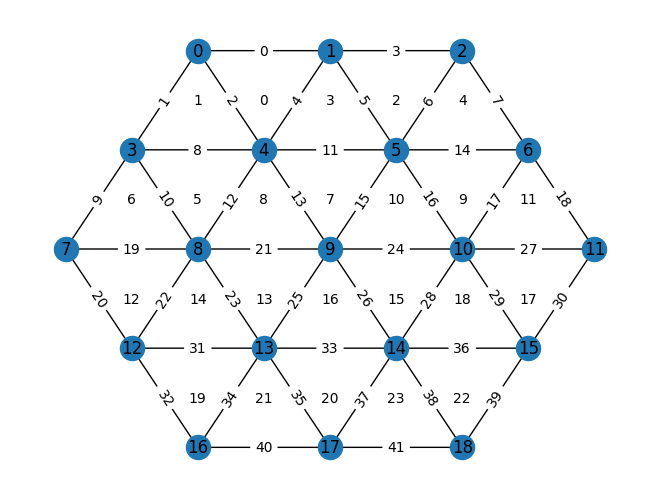

In [5]:
lattice.draw_graph();

In [6]:
sort_idx = np.argsort(probs[0])[::-1]
sorted_probs = probs[0][sort_idx]
for idx, prob in zip(sort_idx[:20], sorted_probs):
    print(np.nonzero((idx >> np.arange(nplaq)) % 2)[0], prob)

[] 0.019312689431863286
[13] 0.0034522225301977863
[20] 0.0034522225301977863
[11] 0.0034522225301977863
[3] 0.0034522225301977863
[23] 0.0034522225301977863
[22] 0.0034522225301977863
[15] 0.0034522225301977863
[14] 0.0034522225301977863
[2] 0.0034522225301977863
[19] 0.0034522225301977863
[1] 0.0034522225301977854
[12] 0.0034522225301977854
[5] 0.0034522225301977854
[6] 0.0034522225301977854
[9] 0.0034522225301977854
[21] 0.0034522225301977854
[0] 0.0034522225301977854
[18] 0.0034522225301977854
[17] 0.0034522225301977854


In [7]:
delta_ts = np.linspace(0.02, 1.62, 17)
key = jax.random.key(1234)
comp_indices = []
comp_indices_1m = []
for delta_t in delta_ts:
    trotter_uvec = make_trotter_uvec(hamiltonian, delta_t)
    sim_states = simulate(trotter_uvec, nplaq, 2, num_substeps=1, dims=(1, 2))
    probs = jnp.square(jnp.abs(sim_states))
    cumprobs = jnp.cumsum(probs, axis=1)
    dt_indices = []
    for istep in range(2):
        key, = jax.random.split(key, num=1)
        rands = jax.random.uniform(key, 100000)
        dt_indices.append(np.unique(jnp.searchsorted(cumprobs[istep], rands)))
    comp_indices.append(dt_indices)
    dt_indices = []
    for istep in range(2):
        key, = jax.random.split(key, num=1)
        rands = jax.random.uniform(key, 200000)
        dt_indices.append(np.unique(jnp.searchsorted(cumprobs[istep], rands)))
    comp_indices_1m.append(dt_indices)

In [8]:
filename = data_dir / 'exact_diag.h5'
with h5py.File(filename, libver='latest') as source:
    exact_eigvals = source[f'eigvals_n{nplaq}'][()]
    exact_eigvecs = source[f'eigvecs_n{nplaq}'][()]

In [9]:
coverages1 = []
coverages2 = []
for idx1, idx2 in comp_indices:
    coverages1.append(np.sum(np.square(np.abs(exact_eigvecs[idx1, 0]))))
    idx = np.unique(np.concatenate([idx1, idx2]))
    coverages2.append(np.sum(np.square(np.abs(exact_eigvecs[idx, 0]))))
coverages1 = np.array(coverages1)
coverages2 = np.array(coverages2)

In [10]:
coverages1_1m = []
coverages2_1m = []
for idx1, idx2 in comp_indices_1m:
    coverages1_1m.append(np.sum(np.square(np.abs(exact_eigvecs[idx1, 0]))))
    idx = np.unique(np.concatenate([idx1, idx2]))
    coverages2_1m.append(np.sum(np.square(np.abs(exact_eigvecs[idx, 0]))))
coverages1_1m = np.array(coverages1_1m)
coverages2_1m = np.array(coverages2_1m)

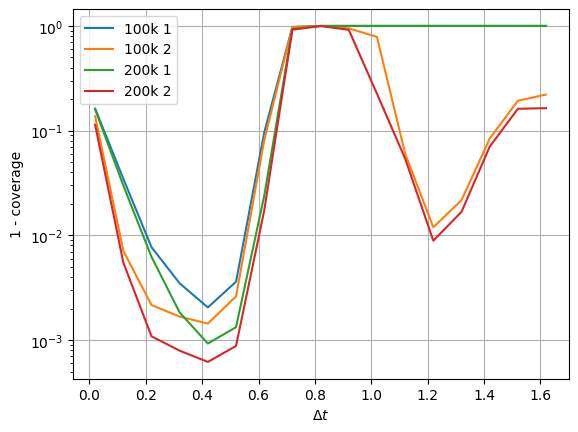

In [12]:
plt.plot(delta_ts, 1. - coverages1, label='100k 1')
plt.plot(delta_ts, 1. - coverages2, label='100k 2')
plt.plot(delta_ts, 1. - coverages1_1m, label='200k 1')
plt.plot(delta_ts, 1. - coverages2_1m, label='200k 2')
plt.xlabel(r'$\Delta t$')
plt.ylabel('1 - coverage')
plt.yscale('log')
plt.grid()
plt.legend();

In [9]:
energies1 = []
energies2 = []
for idx1, idx2 in comp_indices_1m:
    states1 = ((idx1[:, None] >> np.arange(nplaq)[::-1]) % 2).astype(np.uint8)
    energies1.append(sqd(hamiltonian, states1)[0])
    idx = np.unique(np.concatenate([idx1, idx2]))
    states = ((idx[:, None] >> np.arange(nplaq)[::-1]) % 2).astype(np.uint8)
    energies2.append(sqd(hamiltonian, states)[0])

INFO:skqd_z2lgt.sqd:0.617142 seconds to sort 37 bitstrings
INFO:skqd_z2lgt.sqd:4.096869 seconds to diagonalize
INFO:skqd_z2lgt.sqd:0.689763 seconds to sort 151 bitstrings
INFO:skqd_z2lgt.sqd:4.255618 seconds to diagonalize
INFO:skqd_z2lgt.sqd:1.045915 seconds to sort 1050 bitstrings
INFO:skqd_z2lgt.sqd:5.115551 seconds to diagonalize
INFO:skqd_z2lgt.sqd:2.229980 seconds to sort 7511 bitstrings
INFO:skqd_z2lgt.sqd:7.303197 seconds to diagonalize
INFO:skqd_z2lgt.sqd:2.173805 seconds to sort 6702 bitstrings
INFO:skqd_z2lgt.sqd:7.273548 seconds to diagonalize
INFO:skqd_z2lgt.sqd:2.744378 seconds to sort 42217 bitstrings
INFO:skqd_z2lgt.sqd:8.951502 seconds to diagonalize
INFO:skqd_z2lgt.sqd:2.541909 seconds to sort 26985 bitstrings
INFO:skqd_z2lgt.sqd:8.257969 seconds to diagonalize
INFO:skqd_z2lgt.sqd:3.058794 seconds to sort 78937 bitstrings
INFO:skqd_z2lgt.sqd:9.571069 seconds to diagonalize
INFO:skqd_z2lgt.sqd:3.185531 seconds to sort 73952 bitstrings
INFO:skqd_z2lgt.sqd:8.945784 secon

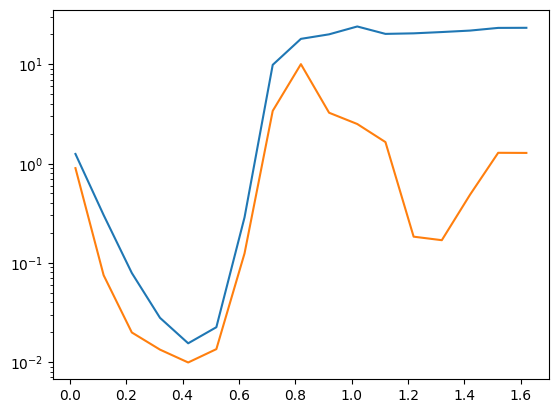

In [12]:
plt.plot(delta_ts, np.array(energies1) - exact_eigvals[0])
plt.plot(delta_ts, np.array(energies2) - exact_eigvals[0])
plt.yscale('log')

In [18]:
concats = []
for cidx in comp_indices:
    idx = np.unique(np.concatenate([comp_indices[4][0], cidx[0]]))
    concats.append(1. - np.sum(np.square(np.abs(exact_eigvecs[idx, 0]))))

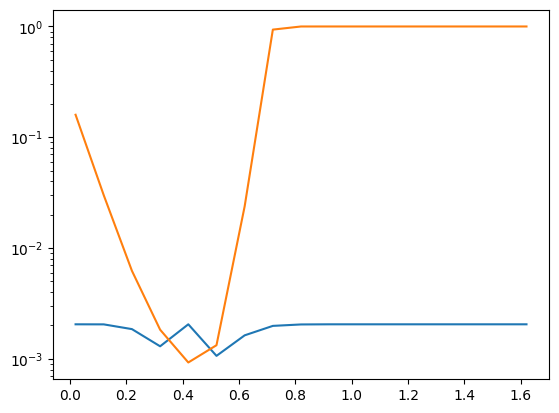

In [22]:
plt.plot(delta_ts, concats)
plt.plot(delta_ts, 1. - coverages1_1m)
plt.yscale('log')

In [17]:
np.unique(np.sum((comp_indices[13][1][:, None] >> np.arange(nplaq)[::-1]) % 2, axis=1), return_counts=True)

(array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9]),
 array([   1,   24,  270, 1302, 1663,  569,   90,   10,    1,    1]))

In [14]:
comp_states[-1].shape

(3502, 24)

In [ ]:
    comp_states.append(np.array((indices[:, None] >> jnp.arange(nplaq)[::-1]) % 2, axis=0))

In [ ]:
for states in comp_states:


[array([[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 1],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         1, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         1, 1],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1,
         0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0,
         0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0,
         0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0,
         0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0,
         0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0,
         0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0,
         0, 0],

In [5]:
histograms = np.zeros((len(delta_ts), 2, nplaq + 1))
for idt in range(len(delta_ts)):
    probs = jnp.square(jnp.abs(sim_states[idt]))
    for istep in range(2):
        excitations = jnp.sum((jnp.arange(2 ** nplaq)[:, None] >> jnp.arange(nplaq)[::-1]) % 2, axis=1)
        exc_probs = jnp.zeros(nplaq + 1)
        histograms[idt, istep] = exc_probs.at[excitations].add(probs[istep])

In [24]:
trotter_uvec = make_trotter_uvec(hamiltonian, 0.4)
sim_state = simulate(trotter_uvec, nplaq, 2, num_substeps=1, dims=(1,))[0]
probs = jnp.square(jnp.abs(sim_state))
cumprobs = jnp.cumsum(probs)
key = jax.random.key(1234)
rands = jax.random.uniform(key, 100000)
indices = jnp.searchsorted(cumprobs, rands)
indices_u = jnp.unique((indices[:, None] >> jnp.arange(nplaq)[::-1]) % 2, axis=0)

In [29]:
jnp.unique(jnp.sum(indices_u, axis=1), return_counts=True)

(Array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12], dtype=int64),
 Array([    1,    24,   276,  2024,  9192, 12618,  8082,  3838,  1526,
          478,   144,    37,     3], dtype=int64))

In [22]:
import math
math.comb(24, 4)

10626

In [8]:
histograms[7, 0]

array([9.62318074e-01, 3.69924664e-02, 6.81388079e-04, 8.00348915e-06,
       6.73010852e-08, 4.31186804e-10, 2.18701225e-12, 9.00759981e-15,
       3.06585366e-17, 8.72996087e-20, 2.09742751e-22, 4.27568511e-25,
       7.41909996e-28, 1.09691385e-30, 1.38044965e-33, 1.47405170e-36,
       1.32806290e-39, 1.00102083e-42, 6.23522389e-46, 3.15379242e-49,
       1.26286381e-52, 3.85283683e-56, 8.41516418e-60, 1.17205544e-63,
       7.82204514e-68])

In [9]:
histograms[7, 1]

array([8.59380141e-01, 1.30630721e-01, 9.52990610e-03, 4.44014294e-04,
       1.48316580e-05, 3.77985450e-07, 7.63590312e-09, 1.25412639e-10,
       1.70410437e-12, 1.93921220e-14, 1.86376150e-16, 1.52120570e-18,
       1.05771181e-20, 6.27110665e-23, 3.16691242e-25, 1.35777234e-27,
       4.91420512e-30, 1.48862898e-32, 3.72785624e-35, 7.58273141e-38,
       1.22130167e-40, 1.49891151e-43, 1.31706942e-46, 7.37960885e-50,
       1.98106950e-53])

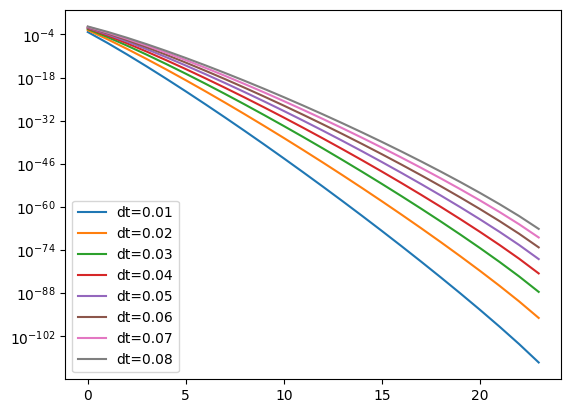

In [15]:
plt.plot(np.arange(nplaq), histograms[:, 0, 1:].T, label=[f'dt={dt:.2f}' for dt in delta_ts])
plt.yscale('log')
plt.legend();

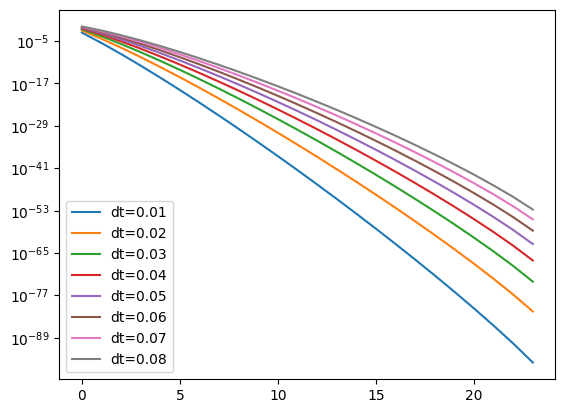

In [16]:
plt.plot(np.arange(nplaq), histograms[:, 1, 1:].T, label=[f'dt={dt:.2f}' for dt in delta_ts])
plt.yscale('log')
plt.legend();

In [17]:
histograms[0, 0]

array([9.99400177e-001, 5.99650101e-004, 1.72402277e-007, 3.16076110e-011,
       4.14856808e-015, 4.14863723e-019, 3.28439254e-023, 2.11143040e-027,
       1.12171609e-031, 4.98548795e-036, 1.86958914e-040, 5.94879187e-045,
       1.61115798e-049, 3.71811885e-054, 7.30356948e-059, 1.21728187e-063,
       1.71183116e-068, 2.01395257e-073, 1.95804208e-078, 1.54584846e-083,
       9.66171390e-089, 4.60089282e-094, 1.56851233e-099, 3.40986625e-105,
       3.55200321e-111])

In [18]:
histograms[4, 0]

array([9.85110400e-01, 1.47828151e-02, 1.06295771e-04, 4.87392017e-07,
       1.59992165e-09, 4.00147130e-12, 7.92287960e-15, 1.27385067e-17,
       1.69253811e-20, 1.88138176e-23, 1.76453057e-26, 1.40418891e-29,
       9.51149192e-33, 5.48968641e-36, 2.69695181e-39, 1.12419831e-42,
       3.95390703e-46, 1.16339855e-49, 2.82888344e-53, 5.58564979e-57,
       8.73121557e-61, 1.03986367e-64, 8.86616851e-69, 4.82057829e-73,
       1.25588218e-77])

In [19]:
histograms[7, 0]

array([9.62318074e-01, 3.69924664e-02, 6.81388079e-04, 8.00348915e-06,
       6.73010852e-08, 4.31186804e-10, 2.18701225e-12, 9.00759981e-15,
       3.06585366e-17, 8.72996087e-20, 2.09742751e-22, 4.27568511e-25,
       7.41909996e-28, 1.09691385e-30, 1.38044965e-33, 1.47405170e-36,
       1.32806290e-39, 1.00102083e-42, 6.23522389e-46, 3.15379242e-49,
       1.26286381e-52, 3.85283683e-56, 8.41516418e-60, 1.17205544e-63,
       7.82204514e-68])